In [ ]:
%pip install transformers torch torchvision torchaudio numpy pandas tqdm matplotlib huggingface_hub datasets evaluate scikit-learn accelerate rouge-score bert-score sentence-transformers

In [2]:
import sys
import os

# Path to the folder you want to add
subfolder_path = os.path.join(os.getcwd(), "byt5_generator")

# Add it to sys.path
if subfolder_path not in sys.path:
    sys.path.append(subfolder_path)

In [3]:
import os
import argparse
import pandas as pd
import transformers

from transformers import AutoModelForSeq2SeqLM
from byt5_generator.seeding import enforce_reproducibility
from byt5_generator.dataset import prepare_datasets
from byt5_generator.train import train_seq2seq, evaluate_seq2seq

transformers.logging.set_verbosity_error()

/Users/xk84vl/Documents/Repos/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/xk84vl/Documents/Repos/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


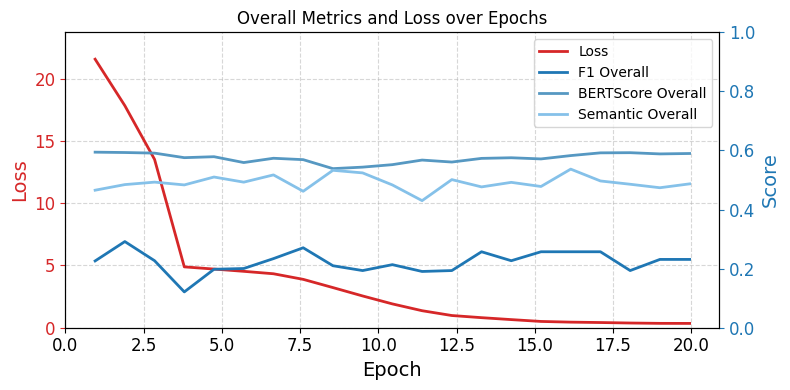

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

output_dir = "byt5_training_results"  # folder to save

# Load your CSV
df = pd.read_csv(f"{output_dir}/train_metrics_per_step.csv")
df['epoch'] = pd.to_numeric(df['epoch'])

# Create figure and axis
fig, ax_loss = plt.subplots(figsize=(8,4))

# Plot Loss on left axis
ax_loss.plot(df['epoch'], df['eval_loss'], color='tab:red', label='Loss', linewidth=2)
ax_loss.set_ylim(0, df['eval_loss'].max()*1.1)
ax_loss.grid(True, linestyle='--', alpha=0.5)
ax_loss.set_ylabel("Loss", color='tab:red', fontsize=14)
ax_loss.set_xlabel("Epoch", fontsize=14)
ax_loss.tick_params(axis='y', colors='tab:red', labelsize=12)
ax_loss.tick_params(axis='x', labelsize=12)

# Create secondary axis for scores
ax_score = ax_loss.twinx()

# Shades of blue for F1, BERTScore, Semantic
ax_score.plot(df['epoch'], df['eval_f1_overall'], label='F1 Overall', color='#1f77b4', linewidth=2)
ax_score.plot(df['epoch'], df['eval_bertscore_overall'], label='BERTScore Overall', color='#5698c2', linewidth=2)
ax_score.plot(df['epoch'], df['eval_semantic_overall'], label='Semantic Overall', color='#85c1e9', linewidth=2)
ax_score.set_ylabel("Score", color='#1f77b4', fontsize=14)
ax_score.tick_params(axis='y', colors='#1f77b4', labelsize=12)
ax_score.set_ylim(0, 1)

# Combine legends
lines_loss, labels_loss = ax_loss.get_legend_handles_labels()
lines_score, labels_score = ax_score.get_legend_handles_labels()
ax_loss.legend(lines_loss + lines_score, labels_loss + labels_score, loc='upper right')

plt.title("Overall Metrics and Loss over Epochs")
plt.tight_layout()

# Save as PDF
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "overall_metrics_loss_plot.pdf"))

plt.show()
